# Setup

In [1]:
# %%capture
# %%bash
# !python3 ./generate_data.py
# !python3 ./run_ddl.py

2025-12-09 08:44:58,664 - __main__ - INFO - Parsed command line arguments
2025-12-09 08:44:58,664 - __main__ - INFO - Starting TPC-H dataset generation pipeline
2025-12-09 08:44:58,664 - __main__ - INFO - Starting TPC-H table creation with scaling factor 0.1
2025-12-09 08:45:02,080 - __main__ - INFO - TPC-H tables created with scaling factor 0.1
2025-12-09 08:45:02,081 - __main__ - INFO - Starting export of TPC-H tables to csv format in ./data
2025-12-09 08:45:02,099 - __main__ - INFO - Found 8 tables to export
2025-12-09 08:45:02,099 - __main__ - INFO - Exporting customer to ./data/customer.csv
2025-12-09 08:45:02,140 - __main__ - INFO - Exported customer to ./data/customer.csv
2025-12-09 08:45:02,140 - __main__ - INFO - Exporting lineitem to ./data/lineitem.csv
2025-12-09 08:45:02,729 - __main__ - INFO - Exported lineitem to ./data/lineitem.csv
2025-12-09 08:45:02,729 - __main__ - INFO - Exporting nation to ./data/nation.csv
2025-12-09 08:45:02,732 - __main__ - INFO - Exported nation

Run Python code as shown below

In [2]:
a = 10

Run SQL code as shown below, with the `%%sql` called magics

In [3]:
%%sql
SELECT
  1

25/12/09 08:45:50 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
                                                                                

1
1


We use the `prod.db` schema where all our tables are create by `run_ddl.py`

In [4]:
%%sql --show
use prod.db

++
||
++
++

## Your code below

In [5]:
%%sql 
show catalogs;

catalog
demo
spark_catalog


In [6]:
%%sql
show schemas IN demo;

namespace
prod


In [7]:
%%sql
show tables IN prod

namespace,tableName,isTemporary


In [8]:
%%sql
show schemas IN prod;

namespace
prod.db


In [9]:
%%sql
show tables IN prod.db

namespace,tableName,isTemporary
prod.db,customer,False
prod.db,lineitem,False
prod.db,nation,False
prod.db,orders,False
prod.db,part,False
prod.db,partsupp,False
prod.db,region,False
prod.db,supplier,False


In [10]:
%%sql --show
SELECT
  *
FROM
  prod.db.customer
LIMIT
  2

c_custkey,c_name,c_address,c_nationkey,c_phone,c_acctbal,c_mktsegment,c_comment
1,Customer#000000001,j5JsirBM9PsCy0O1m,15,25-989-741-2988,711.56,BUILDING,y final requests wake slyly quickly special accounts. blithely
2,Customer#000000002,487LW1dovn6Q4dMVymKwwLE9OKf3QG,13,23-768-687-3665,121.65,AUTOMOBILE,y carefully regular foxes. slyly regular requests about the bli


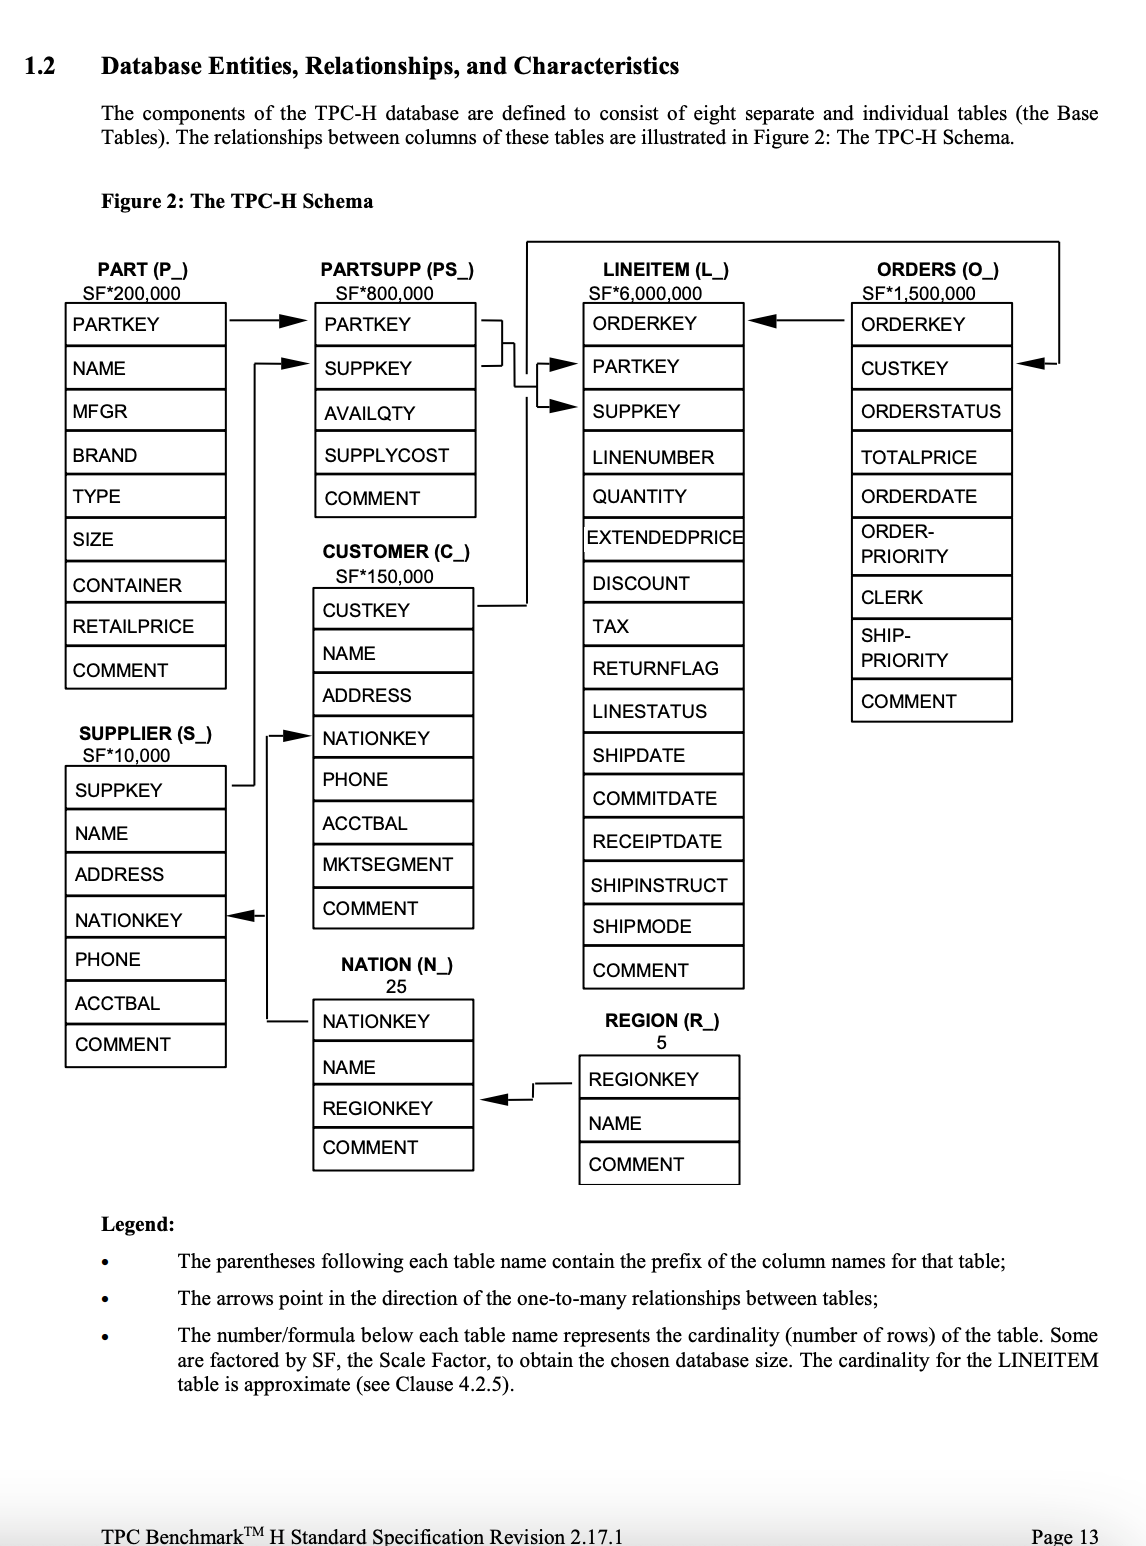

In [11]:
%%sql
DESCRIBE extended lineitem

col_name,data_type,comment
l_orderkey,bigint,None
l_partkey,bigint,None
l_suppkey,bigint,None
l_linenumber,int,None
l_quantity,"decimal(15,2)",None
l_extendedprice,"decimal(15,2)",None
l_discount,"decimal(15,2)",None
l_tax,"decimal(15,2)",None
l_returnflag,string,None
l_linestatus,string,None


In [12]:
%%sql 
WITH
  orders_cte AS (
    SELECT
      o_orderkey,
      o_custkey,
      o_orderstatus,
      CAST(o_orderdate AS TIMESTAMP) AS o_orderdate,
      o_orderpriority,
      o_clerk,
      o_shippriority,
      o_comment,
      o_totalprice
    FROM
      orders
  ),
  stg_customers AS (
    SELECT
      c_custkey,
      c_name,
      c_address,
      c_nationkey,
      c_phone,
      c_acctbal,
      c_mktsegment,
      c_comment
    FROM
      customer
  ),
  nation_cte AS (
    SELECT
      CAST(n_nationkey AS INT) AS n_nationkey,
      CAST(n_name AS STRING) AS n_name,
      CAST(n_regionkey AS INT) AS n_regionkey,
      CAST(n_comment AS STRING) AS n_comment
    FROM
      nation
  ),
  dim_customers AS (
    SELECT
      c.c_custkey,
      c.c_name,
      c.c_address,
      c.c_nationkey,
      n.n_name AS nation_name,
      c.c_phone,
      c.c_acctbal,
      c.c_mktsegment,
      c.c_comment
    FROM
      stg_customers c
      INNER JOIN nation_cte n ON c.c_nationkey = n.n_nationkey
  )
SELECT
  o.o_orderkey,
  o.o_custkey,
  o.o_orderstatus,
  o.o_orderdate,
  o.o_orderpriority,
  o.o_clerk,
  o.o_shippriority,
  o.o_totalprice,
  c.c_name AS customer_name,
  c.c_address AS customer_address,
  c.c_phone AS customer_phone,
  c.c_acctbal AS customer_account_balance,
  c.c_mktsegment AS customer_market_segment,
  c.nation_name AS customer_nation_name
FROM
  orders_cte o
  INNER JOIN dim_customers c ON o.o_custkey = c.c_custkey;

o_orderkey,o_custkey,o_orderstatus,o_orderdate,o_orderpriority,o_clerk,o_shippriority,o_totalprice,customer_name,customer_address,customer_phone,customer_account_balance,customer_market_segment,customer_nation_name
897,4894,P,1995-03-20 00:00:00,1-URGENT,Clerk#000000316,0,66775.72,Customer#000004894,qccDi3BeqTSkIJKsp21j4KBsQpPk0Gt,30-152-685-8820,7927.44,HOUSEHOLD,SAUDI ARABIA
4034,9233,F,1993-11-14 00:00:00,4-NOT SPECIFIED,Clerk#000000548,0,307637.71,Customer#000009233,1Ba3hAO5jmBFJpKq2QIdZlb3Z,33-327-912-9200,4227.72,FURNITURE,UNITED KINGDOM
4769,12044,P,1995-04-14 00:00:00,4-NOT SPECIFIED,Clerk#000000116,0,206126.35,Customer#000012044,u9bevlA h3PS,10-488-427-2414,4825.26,MACHINERY,ALGERIA
5123,964,O,1998-02-10 00:00:00,1-URGENT,Clerk#000000776,0,18908.75,Customer#000000964,"2DpdvfAw4TuXl8DV,YVBwGsK7oLzkYr",22-974-772-2802,4756.58,FURNITURE,JAPAN
6695,1697,F,1992-06-28 00:00:00,5-LOW,Clerk#000000877,0,322140.76,Customer#000001697,8aHZSJIoZKtIfcD8IFMCu,34-288-313-5272,-913.24,FURNITURE,UNITED STATES
6821,12568,O,1997-10-02 00:00:00,2-HIGH,Clerk#000000256,0,70652.83,Customer#000012568,4sXc57EIjaq27SZOVapVbyq2D9c76iVS7a3,12-653-119-1864,4980.83,FURNITURE,BRAZIL
11143,964,F,1992-11-27 00:00:00,5-LOW,Clerk#000000613,0,129516.39,Customer#000000964,"2DpdvfAw4TuXl8DV,YVBwGsK7oLzkYr",22-974-772-2802,4756.58,FURNITURE,JAPAN
12961,11434,F,1994-12-13 00:00:00,2-HIGH,Clerk#000000913,0,156148.09,Customer#000011434,6IuGcZvmcJzMBDIYWuu2gl,20-123-656-9998,8580.24,AUTOMOBILE,IRAN
13728,26,O,1995-12-11 00:00:00,2-HIGH,Clerk#000000094,0,122064.03,Customer#000000026,TFH OW1MeFU6OIb,32-363-455-4837,5182.05,AUTOMOBILE,RUSSIA
15651,14846,F,1992-10-05 00:00:00,1-URGENT,Clerk#000000592,0,96790.11,Customer#000014846,MJmSOptlNEaAsx,15-972-996-4702,9021.18,HOUSEHOLD,ETHIOPIA


# Exercises Chapter: Read data, Combine tables, & aggregate numbers to understand business performance

## 1. Number of items returned for each region name

In [81]:
%%sql
SELECT r.r_name AS region_name,
        COUNT(l.l_partkey) AS number_item_returned
FROM region AS r
INNER JOIN nation AS n
ON r.r_regionkey = n.n_regionkey
INNER JOIN customer AS c
ON c.c_nationkey = n.n_nationkey
INNER JOIN orders AS o
ON c.c_custkey = o.o_custkey
INNER JOIN lineitem AS l
ON o.o_orderkey = l.l_orderkey
WHERE l.l_returnflag = 'R'
GROUP BY 1
ORDER BY 2 DESC;

region_name,number_item_returned
MIDDLE EAST,30414
ASIA,29786
AFRICA,29624
EUROPE,29259
AMERICA,29218


### Solution question 1:

In [87]:
%%sql
-- Compare with solution
SELECT
r_name AS region_name,
COUNT(*) AS items_returned
FROM
lineitem l
INNER JOIN orders o ON l_orderkey = o_orderkey
INNER JOIN customer c ON o_custkey = c_custkey
INNER JOIN nation n ON c_nationkey = n_nationkey
INNER JOIN region r ON n_regionkey = r_regionkey
WHERE
l_returnflag = 'R' -- R for return
GROUP BY
r_name
ORDER BY
items_returned DESC;

region_name,items_returned
MIDDLE EAST,30414
ASIA,29786
AFRICA,29624
EUROPE,29259
AMERICA,29218


## 2. Top 10 selling parts (part name)

In [35]:
%%sql
CREATE OR REPLACE TEMP VIEW top10 AS
    SELECT l.l_partkey AS part_key,
           p.p_name AS part_name,
           SUM(l.l_quantity) AS total_quantity
    FROM lineitem AS l
    INNER JOIN part AS p
        ON p.p_partkey = l.l_partkey
    GROUP BY 1,2 
    ORDER BY 3 DESC
    LIMIT 10;

++
||
++
++

In [38]:
%%sql
SELECT * FROM top10;

part_key,part_name,total_quantity
17413,snow blanched blush linen blue,1484.00
19611,moccasin brown puff thistle steel,1465.00
10620,floral azure papaya moccasin indian,1427.00
15717,blanched white ghost frosted metallic,1420.00
15584,hot blue honeydew salmon slate,1413.00
9195,lavender green brown linen dark,1412.00
1550,frosted chocolate spring peach lawn,1398.00
8134,hot blanched magenta yellow metallic,1389.00
7781,orange white medium plum drab,1385.00
8554,brown hot olive tan black,1382.00


### Solution question 2:

In [88]:
%%sql
-- Compare with solution
SELECT
p_name AS part_name,
SUM(l_quantity) AS total_quantity_sold
FROM
lineitem l
INNER JOIN part p ON l_partkey = p_partkey
GROUP BY
p_partkey,
p_name
ORDER BY
total_quantity_sold DESC
LIMIT 10;

part_name,total_quantity_sold
snow blanched blush linen blue,1484.00
moccasin brown puff thistle steel,1465.00
floral azure papaya moccasin indian,1427.00
blanched white ghost frosted metallic,1420.00
hot blue honeydew salmon slate,1413.00
lavender green brown linen dark,1412.00
frosted chocolate spring peach lawn,1398.00
hot blanched magenta yellow metallic,1389.00
orange white medium plum drab,1385.00
brown hot olive tan black,1382.00


## 3. Sellers (name) who have sold at least one of the top 10 selling parts

In [44]:
%%sql
SELECT t.part_key AS part_key,
        t.part_name AS part_name,
    ps.ps_suppkey AS supplier_key,
    s.s_name AS supplier_name
FROM top10 AS t
INNER JOIN partsupp AS ps
ON t.part_key = ps.ps_partkey
INNER JOIN supplier AS s
ON s.s_suppkey = ps.ps_suppkey

part_key,part_name,supplier_key,supplier_name
1550,frosted chocolate spring peach lawn,551,Supplier#000000551
1550,frosted chocolate spring peach lawn,802,Supplier#000000802
1550,frosted chocolate spring peach lawn,53,Supplier#000000053
1550,frosted chocolate spring peach lawn,304,Supplier#000000304
7781,orange white medium plum drab,782,Supplier#000000782
7781,orange white medium plum drab,39,Supplier#000000039
7781,orange white medium plum drab,296,Supplier#000000296
7781,orange white medium plum drab,553,Supplier#000000553
8134,hot blanched magenta yellow metallic,135,Supplier#000000135
8134,hot blanched magenta yellow metallic,393,Supplier#000000393


### Solution question 3:

In [90]:
%%sql
SELECT DISTINCT
s.s_name AS seller_name,
t.total_quantity_sold
FROM
lineitem l
INNER JOIN supplier s ON l.l_suppkey = s.s_suppkey
INNER JOIN (
SELECT
p_partkey,
p_name,
SUM(l_quantity) AS total_quantity_sold
FROM
lineitem l
INNER JOIN part p ON l.l_partkey = p.p_partkey
GROUP BY
p_partkey,
p_name) t ON l.l_partkey = t.p_partkey
ORDER BY
t.total_quantity_sold DESC
LIMIT 10;

seller_name,total_quantity_sold
Supplier#000000215,1484.00
Supplier#000000681,1484.00
Supplier#000000414,1484.00
Supplier#000000948,1484.00
Supplier#000000881,1465.00
Supplier#000000150,1465.00
Supplier#000000419,1465.00
Supplier#000000612,1465.00
Supplier#000000401,1427.00
Supplier#000000141,1427.00


## 4. Number of items returned for each order price bucket. The definition of order price bucket is shown below

```
CASE
    WHEN o_totalprice > 100000 THEN 'high'
    WHEN o_totalprice BETWEEN 25000 AND 100000 THEN 'medium'
    ELSE 'low'
END AS order_price_bucket
```

In [56]:
%%sql
SELECT
    o.o_orderkey,
    o.o_totalprice,
    o.order_price_bucket,
    COALESCE(l.number_return,0) AS number_return
FROM
    (
        SELECT o_orderkey,
               o_totalprice,
               CASE
                   WHEN o_totalprice > 100000 THEN 'high'
                   WHEN o_totalprice BETWEEN 25000 AND 100000 THEN 'medium'
                   ELSE 'low'
               END AS order_price_bucket
        FROM orders
    ) AS o
LEFT JOIN
    (
        SELECT l_orderkey,
               COUNT(*) AS number_return
        FROM lineitem
        WHERE l_shipinstruct ILIKE '%return%'
        GROUP BY 1
    ) AS l
ON o.o_orderkey = l.l_orderkey
ORDER BY o.o_orderkey;

o_orderkey,o_totalprice,order_price_bucket,number_return
1,194029.55,high,2
2,60951.63,medium,1
3,247296.05,high,3
4,53829.87,medium,0
5,139660.54,high,0
6,65843.52,medium,1
7,231037.28,high,3
32,166802.63,high,1
33,118518.56,high,2
34,75662.77,medium,0


### Solution question 4:

In [92]:
%%sql
SELECT
CASE
WHEN o_totalprice > 100000 THEN 'high'
WHEN o_totalprice BETWEEN 25000 AND 100000 THEN 'medium'
ELSE 'low'
END AS order_price_bucket,
COUNT(*) AS items_returned
FROM
lineitem l
INNER JOIN orders o ON l_orderkey = o_orderkey
WHERE
l_returnflag = 'R'
GROUP BY
CASE
WHEN o_totalprice > 100000 THEN 'high'
WHEN o_totalprice BETWEEN 25000 AND 100000 THEN 'medium'
ELSE 'low'
END 
ORDER BY 
items_returned DESC;

order_price_bucket,items_returned
high,121779
medium,23777
low,2745


## 5. Average time (in days) between receipt date and ship date for each nation (name)

In [73]:
%%sql 
with total AS(
    SELECT  n.n_nationkey,
        n.n_name,
        DATEDIFF(DAY, l.l_shipdate,l.l_receiptdate) AS days_diff
    FROM lineitem AS l
    INNER JOIN orders AS o
    ON l.l_orderkey = o.o_orderkey
    INNER JOIN customer AS c
    ON o.o_custkey = c.c_custkey
    INNER JOIN nation AS n
    ON c.c_nationkey = n.n_nationkey)

SELECT n_name AS nation_name,
        ROUND(AVG(days_diff),2) AS avg_days_between_receiptdate_shipdate
FROM total
GROUP BY 1 

nation_name,avg_days_between_receiptdate_shipdate
JAPAN,15.45
JORDAN,15.49
UNITED KINGDOM,15.53
CANADA,15.48
ALGERIA,15.49
MOROCCO,15.51
FRANCE,15.58
MOZAMBIQUE,15.59
CHINA,15.6
SAUDI ARABIA,15.53


### Solution question 5:

In [93]:
%%sql
SELECT
n_name AS nation_name,
ROUND(AVG(DATEDIFF (l_receiptdate, l_shipdate)), 2) AS avg_delivery_days
FROM
lineitem l
INNER JOIN orders o ON l_orderkey = o_orderkey
INNER JOIN customer c ON o_custkey = c_custkey
INNER JOIN nation n ON c_nationkey = n_nationkey
WHERE
l_receiptdate IS NOT NULL
AND l_shipdate IS NOT NULL
GROUP BY
n_name
ORDER BY
avg_delivery_days ASC
LIMIT 10;

nation_name,avg_delivery_days
BRAZIL,15.37
VIETNAM,15.39
IRAN,15.44
JAPAN,15.45
ETHIOPIA,15.45
UNITED STATES,15.46
EGYPT,15.46
CANADA,15.48
RUSSIA,15.48
JORDAN,15.49
